# Step 1: Import Libraries

In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

%matplotlib inline 
# is an IPython magic command used in Jupyter Notebooks to display plots directly beneath the code cell that generated them.

# Step 2: Load Dataset

In [10]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Step 3: Dataset Information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Step 4: Check Missing Values

In [12]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Step 5: Statistical Summary

In [13]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Step 6: Select Features for Clustering

In [15]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Step 7: Visualize Original Data

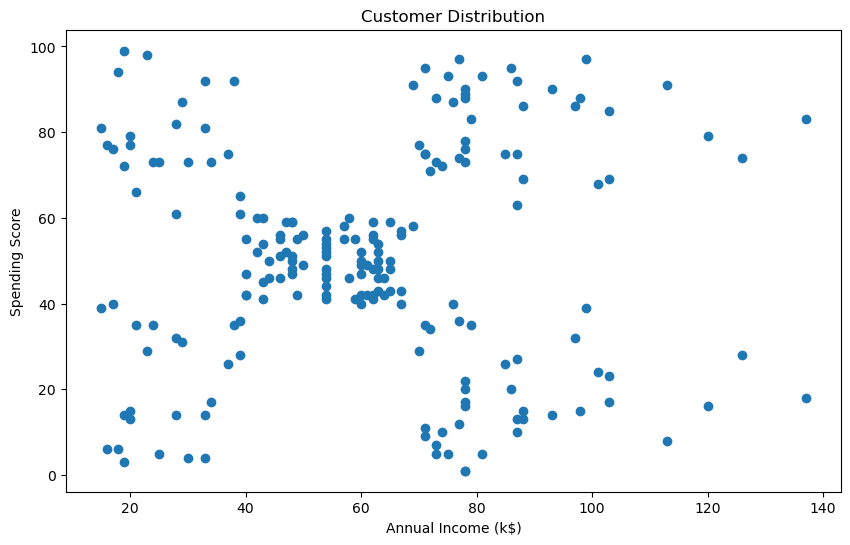

In [16]:
plt.figure(figsize = (10,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.title("Customer Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

# Step 8: Feature Scaling

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


# Step 9: Find Best EPS using K-Distance Graph

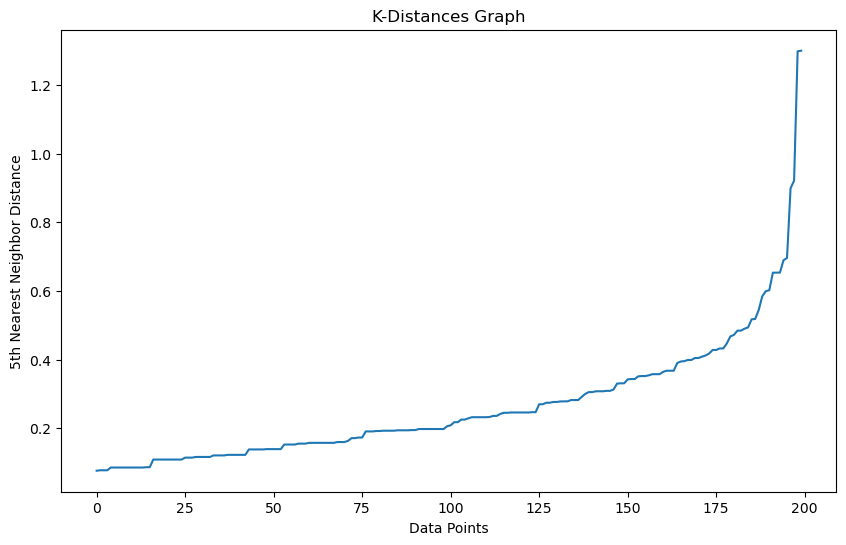

In [22]:
neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])

plt.figure(figsize = (10,6))

plt.plot(distances)

plt.title("K-Distances Graph")
plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")

plt.show()

In [23]:
# Interpretation :

# => Look for the elbow point in graph.

# => Typical value for this dataset:

eps = 0.3

In [ ]:
or

In [24]:
eps = 0.4

# Step 10: Train DBSCAN Model

In [26]:
dbscan = DBSCAN(
    eps = 0.35,
    min_samples = 5
)

clusters = dbscan.fit_predict(X_scaled)

print(clusters)

[ 2  0  1  0  2  0  1 -1  1  0  1 -1  1  0  1  0  2  0  2 -1  2  0  1  0
  1  0  2  0  2  0  1  0  1 -1  1  0  1  0 -1  0  3 -1  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  4  3  4  3  4  5  4  5  4  3  4  5  4  5  4  5  4  5  4  3  4
  5  4  3  4  5  4  5  4  5  4  5  4  5  4  5  4  3  4  5  4  5  4  5  4
  5 -1  5  4  5  4  5  4  5  4  5  4 -1  4  5  4 -1 -1 -1 -1 -1  4 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]


# Step 11: Add Cluster Labels

In [27]:
df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,2


# Step 12: Number of Clusters

In [29]:
print("Unique Clusters :")

print(np.unique(clusters))

Unique Clusters :
[-1  0  1  2  3  4  5]


# Step 13: Cluster Counts

In [30]:
df['Cluster'].value_counts()

 3    88
 4    31
-1    23
 5    23
 0    16
 1    12
 2     7
Name: Cluster, dtype: int64

# Step 14: Visualize DBSCAN Clusters

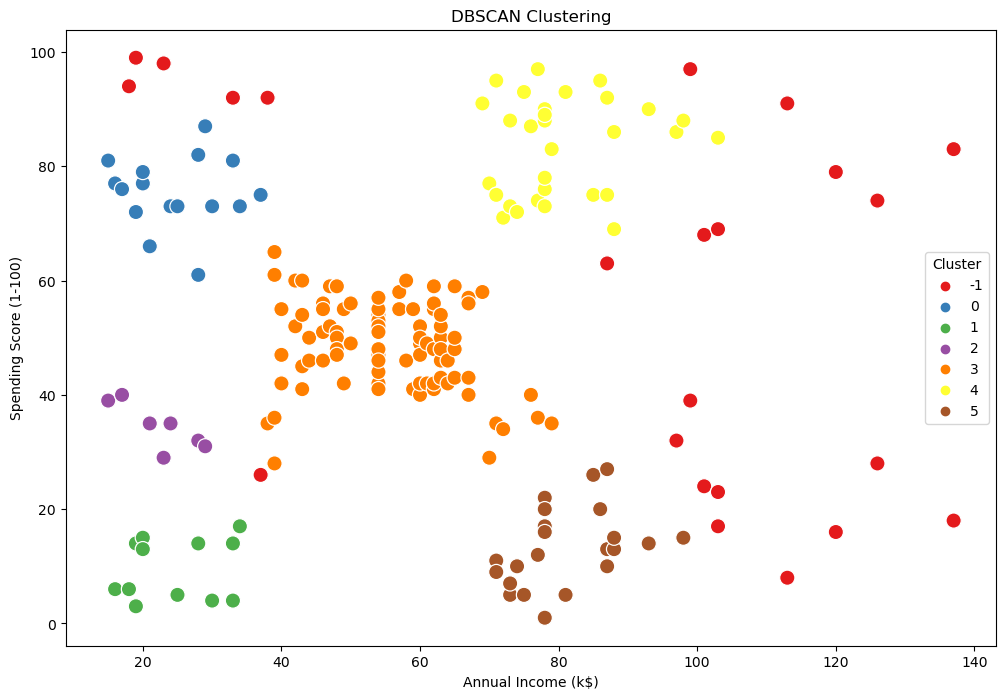

In [31]:
plt.figure(figsize = (12,8))

sns.scatterplot(
    x = 'Annual Income (k$)',
    y = 'Spending Score (1-100)',
    hue = 'Cluster',
    palette = 'Set1',
    data = df,
    s = 120
)

plt.title("DBSCAN Clustering")

plt.show()

# Step 15: Highlight Noise Points

In [32]:
noise = df[df['Cluster'] == -1]

print("Numver of Noise Points :", len(noise))

noise.head()

Numver of Noise Points : 23


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
7,8,Female,23,18,94,-1
11,12,Female,35,19,99,-1
19,20,Female,35,23,98,-1
33,34,Male,18,33,92,-1
38,39,Female,36,37,26,-1


# Step 16: Cluster Centroid Analysis

In [34]:
cluster_analysis = df.groupby('Cluster')[
    ['Annual Income (k$)',
     'Spending Score (1-100)',
     'Age']
].mean()

cluster_analysis

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
-1,89.260870,57.826087,34.434783
0,24.750000,75.375000,24.812500
1,24.583333,9.583333,48.750000
2,22.428571,34.428571,36.714286
3,55.227273,48.579545,42.875000
4,80.290323,83.193548,32.838710
5,80.956522,12.782609,41.217391


# Step 17: Age Distribution

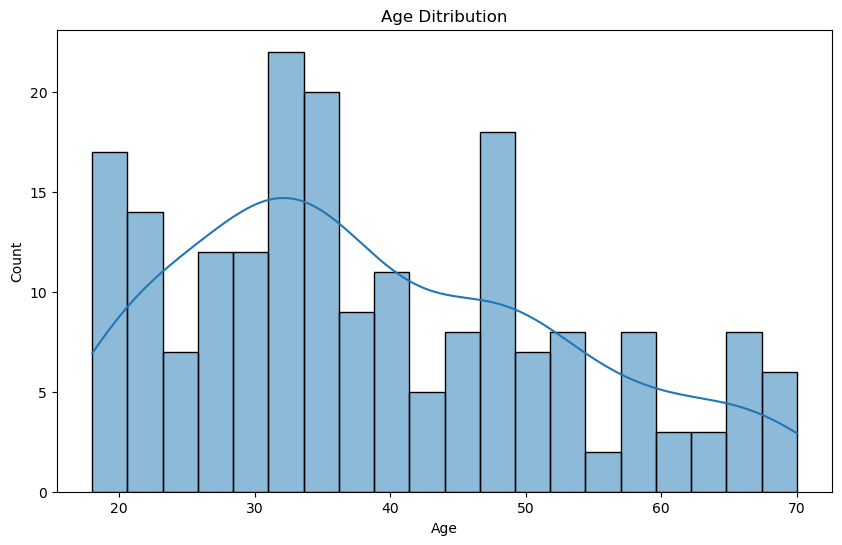

In [37]:
plt.figure(figsize = (10,6))

sns.histplot(
    df['Age'],
    bins = 20,
    kde = True
)

plt.title("Age Ditribution")

plt.show()

# Step 18: Income Distribution

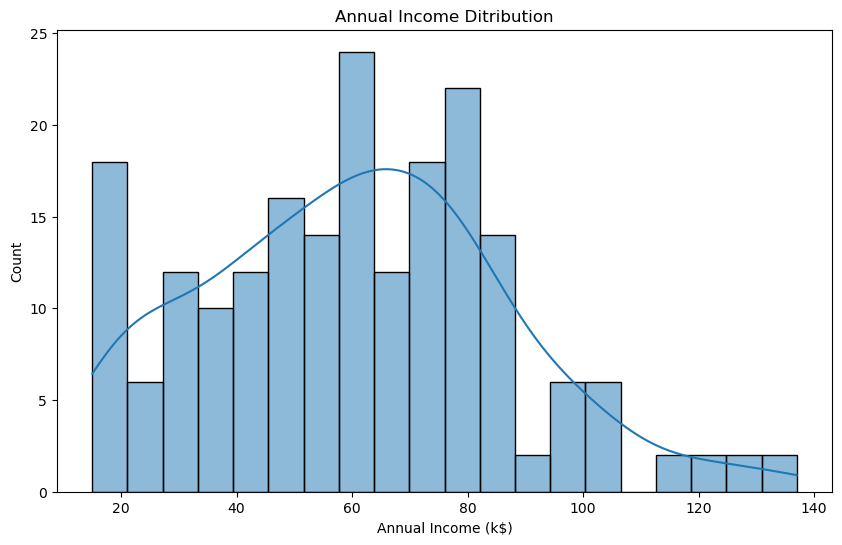

In [39]:
plt.figure(figsize = (10,6))

sns.histplot(
    df['Annual Income (k$)'],
    bins = 20,
    kde = True
)

plt.title("Annual Income Ditribution")

plt.show()

# Step 19: Spending Score Distribution

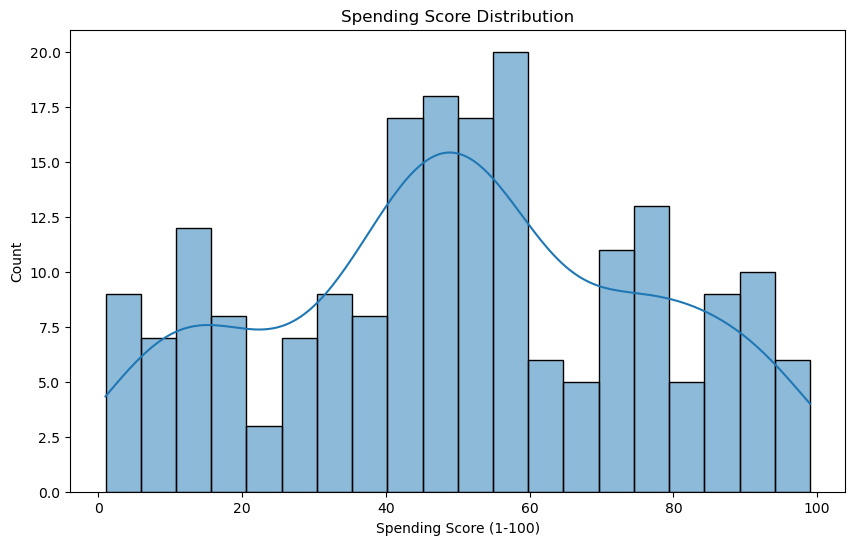

In [40]:
plt.figure(figsize = (10,6))

sns.histplot(
    df['Spending Score (1-100)'],
    bins = 20,
    kde = True
)

plt.title("Spending Score Distribution")

plt.show()

# Step 20: Final Customer Segments

In [41]:
for cluster in sorted(df['Cluster'].unique()):
    print(f"\nCluster {cluster}")
    
    display(df[df['Cluster'] == cluster].head())


Cluster -1


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
7,8,Female,23,18,94,-1
11,12,Female,35,19,99,-1
19,20,Female,35,23,98,-1
33,34,Male,18,33,92,-1
38,39,Female,36,37,26,-1



Cluster 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
1,2,Male,21,15,81,0
3,4,Female,23,16,77,0
5,6,Female,22,17,76,0
9,10,Female,30,19,72,0
13,14,Female,24,20,77,0



Cluster 1


...

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
40,41,Female,65,38,35,3
42,43,Male,48,39,36,3
43,44,Female,31,39,61,3
44,45,Female,49,39,28,3
45,46,Female,24,39,65,3



Cluster 4


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
123,124,Male,39,69,91,4
125,126,Female,31,70,77,4
127,128,Male,40,71,95,4
129,130,Male,38,71,75,4
131,132,Male,39,71,75,4



Cluster 5


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
128,129,Male,59,71,11,5
130,131,Male,47,71,9,5
134,135,Male,20,73,5,5
136,137,Female,44,73,7,5
138,139,Male,19,74,10,5


# DBSCAN Parameter Explanation

| Parameter     | Meaning                                 |
| ------------- | --------------------------------------- |
| eps           | Radius around each point                |
| min_samples   | Minimum points required to form cluster |
| metric        | Distance metric                         |
| fit_predict() | Train + Predict                         |
| -1 Label      | Noise / Outlier                         |
| 0,1,2,3...    | Cluster IDs                             |
